# localtunnel 사용

https://discuss.streamlit.io/t/how-to-launch-streamlit-app-from-google-colab-notebook/42399


# ngrok 사용

**기본 원리:**

Google Colab은 가상 머신 환경을 제공하며, 이 가상 머신은 외부에서 직접 접속하기 어렵습니다. 따라서 Streamlit 앱을 외부에서 접속 가능하게 하려면 "터널링"이라는 기술을 사용해야 합니다. 가장 흔하게 사용되는 방법은 `ngrok`을 이용하는 것입니다. `localtunnel`도 가능하지만, `ngrok`이 더 널리 사용되고 안정적입니다.

**단계별 설명:**

1.  **Streamlit 앱 설치 및 작성:**
    먼저 Colab 노트북에서 Streamlit을 설치하고 앱을 작성해야 합니다.

    ```python
    !pip install streamlit
    ```

    예시 `app.py` 파일 생성:

    ```python
    %%writefile app.py
    import streamlit as st

    st.title("My Streamlit App on Colab")
    st.write("Hello from Google Colab!")

    name = st.text_input("Enter your name:")
    if name:
        st.write(f"Hello, {name}!")
    ```

2.  **`ngrok` 설치 및 인증:**
    `ngrok`을 설치하고, `ngrok` 웹사이트에서 발급받은 인증 토큰을 연결해야 합니다.

    ```python
    !pip install pyngrok
    ```

    `ngrok` 토큰 설정 (회원가입 후 [https://dashboard.ngrok.com/get-started/your-authtoken](https://dashboard.ngrok.com/get-started/your-authtoken) 에서 토큰을 얻을 수 있습니다):

    ```python
    from pyngrok import ngrok
    ngrok_auth_token = "YOUR_NGROK_AUTH_TOKEN" # 여기에 실제 ngrok 토큰을 입력하세요
    ngrok.set_auth_token(ngrok_auth_token)
    ```

3.  **Streamlit 앱 실행 및 `ngrok` 터널링:**
    이제 Streamlit 앱을 백그라운드에서 실행하고, `ngrok`을 사용하여 터널을 생성합니다. Streamlit은 기본적으로 8501 포트를 사용합니다.

    ```python
    # Streamlit 앱을 백그라운드에서 실행
    !streamlit run app.py &

    # ngrok 터널 시작
    public_url = ngrok.connect(port=8501)
    print(f"Streamlit App Public URL: {public_url}")
    ```

    `- &`는 백그라운드에서 명령을 실행하도록 합니다. 이렇게 해야 Streamlit 앱이 실행되는 동안 다음 셀에서 `ngrok`을 실행할 수 있습니다.

4.  **외부 접속:**
    위 코드를 실행하면 `Streamlit App Public URL:` 뒤에 `https://RANDOM_STRING.ngrok-free.app`와 같은 형태의 URL이 출력됩니다. 이 URL을 웹 브라우저에 입력하면 외부에서 Colab에서 실행 중인 Streamlit 앱에 접속할 수 있습니다.

**주의사항:**

  * **Colab 런타임 종료:** Colab 런타임이 종료되면 Streamlit 앱도 종료되고 `ngrok` 터널도 끊어집니다. 따라서 세션을 유지해야 합니다.
  * **무료 `ngrok` 제한:** 무료 `ngrok` 계정은 세션 시간이 제한될 수 있으며, 터널 URL이 세션마다 변경됩니다. 장기적인 사용이나 고정된 URL이 필요하다면 `ngrok` 유료 플랜을 고려해야 합니다.
  * **보안:** `ngrok`을 통해 외부에 노출되는 앱이므로, 중요한 정보나 민감한 데이터를 다루는 앱이라면 보안에 각별히 유의해야 합니다.
  * **Streamlit 포트:** Streamlit은 기본적으로 8501 포트를 사용하지만, 다른 포트를 사용하도록 설정할 수도 있습니다. 이 경우 `ngrok.connect()` 함수의 `port` 인자도 해당 포트 번호로 변경해야 합니다.

이 단계를 따르면 Google Colab 터미널을 통해 Streamlit 앱을 시작하고 외부에서 성공적으로 접속할 수 있습니다.

In [2]:
import pandas as pd
df = pd.read_csv('bmi20000.csv')

In [ ]:
# df['label'].replace({'thin': 1, 'normal':2, 'fat': 3})

C:\Users\USER\AppData\Local\Temp\ipykernel_12776\1684143749.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['label'].replace({'thin': 1, 'normal':2, 'fat': 3})


0        3
1        3
2        3
3        3
4        3
        ..
19995    1
19996    3
19997    3
19998    3
19999    2
Name: label, Length: 20000, dtype: int64

In [4]:
x = df[['height', 'weight']].values
y = df[['label']].values

In [5]:
from sklearn import svm

clf = svm.SVC()
clf.fit(x,y)

c:\Users\USER\miniconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [6]:
import pickle
file_name = "bmi20000_svm.pkl"
with open(file_name, "wb") as f:
    pickle.dump(clf,f)

In [7]:
with open(file_name, 'rb') as f:
    loaded_clf = pickle.load(f)

In [8]:
type(loaded_clf)

sklearn.svm._classes.SVC

In [10]:
pred = loaded_clf.predict(x)

In [14]:
x[0], y[0]

(array([131,  67]), array(['fat'], dtype=object))

In [ ]:
import streamlit as st

filename_pickle = 'bmi20000_svm.pkl'
loaded_model_pickle = None
with open(filename_pickle, 'rb') as file:
    loaded_model_pickle = pickle.load(file)
print(f'모델이 {filename_pickle}에서 성공적으로 불어와짐')

st.header('bmi data')
st_height = st.slider('키', 100, 220, 160)
st_weight = st.slider('몸무게', 40, 120, 60)

if st.button('bmi 예측하기'):
    bmi_dict = {'thin': 1, 'normal':2, 'fat':3}
    reverse_mapping_dict = {value: key for key, value in bmi_dict.items()}
    features = ([st_height, st_weight])
    prediction = loaded_model_pickle.predict(features)
    st.success(f'st{st.height}, {st_weight} : {reverse_mapping_dict}')

In [1]:
import numpy as np
import pandas as pd

titanic = pd.read_csv('d/titanic.csv')
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
titanic.isna()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
titanic.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [9]:
titanic.Age.min(), titanic.Age.max()

(np.float64(0.42), np.float64(80.0))

In [21]:
# age - age에서 0보다 큰 경우
outlier = titanic[titanic.Age - np.floor(titanic.Age) > 0]
outlier.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25 entries, 57 to 843
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  25 non-null     int64  
 1   Survived     25 non-null     int64  
 2   Pclass       25 non-null     int64  
 3   Name         25 non-null     object 
 4   Sex          25 non-null     object 
 5   Age          25 non-null     float64
 6   SibSp        25 non-null     int64  
 7   Parch        25 non-null     int64  
 8   Ticket       25 non-null     object 
 9   Fare         25 non-null     float64
 10  Cabin        4 non-null      object 
 11  Embarked     25 non-null     object 
dtypes: float64(2), int64(5), object(5)
memory usage: 2.5+ KB


In [22]:
titanic = titanic[titanic.Age - np.floor(titanic.Age) == 0] # 이상치 처리값
titanic.info() # 687이어야 한다는데 689가 나옴;

<class 'pandas.core.frame.DataFrame'>
Index: 689 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  689 non-null    int64  
 1   Survived     689 non-null    int64  
 2   Pclass       689 non-null    int64  
 3   Name         689 non-null    object 
 4   Sex          689 non-null    object 
 5   Age          689 non-null    float64
 6   SibSp        689 non-null    int64  
 7   Parch        689 non-null    int64  
 8   Ticket       689 non-null    object 
 9   Fare         689 non-null    float64
 10  Cabin        181 non-null    object 
 11  Embarked     687 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 70.0+ KB


In [34]:
titanic.drop(['Name','Ticket','Cabin'], axis=1, inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_12716\3834135743.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  titanic.drop(['Name','Ticket','Cabin'], axis=1, inplace=True)


In [35]:
# 70%의 학습 데이터셋
A = titanic[:481]
B = titanic[481:]
A.shape, B.shape

((481, 9), (208, 9))

In [36]:
X = titanic.drop('Survived', axis=1).values
y = titanic.Survived.values

In [37]:
from sklearn.model_selection import train_test_split
# 학습용data 평가용data 학습용 label 평가용 label
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.7, shuffle=True, random_state=52)

In [38]:
X_train.shape, X_test.shape

((482, 8), (207, 8))

------------ 아래는 강사님이 작성한 코드들 축약버전 --------------

In [ ]:
# 데이터를 읽어 옵니다.
titanic = pd.read_csv("./data/titanic.csv")

# 1. 피처 삭제를 제거합니다.
titanic = titanic.drop(['Cabin'], axis=1)
titanic = titanic.drop(['Name'], axis=1)
titanic = titanic.drop(['Ticket'], axis=1)

# 2. 결측값이 존재하는 샘플 제거합니다.
titanic = titanic.dropna()

# 3. 이상치 삭제
titanic = titanic[ titanic['Age'] - np.floor(titanic['Age']) == 0 ]
from sklearn.model_selection import train_test_split

# 훈련 데이터 분할: X, y
X = titanic.drop(['Survived'], axis=1).values
y = titanic['Survived'].values

# 학습용data, 평가용data, 학습용label, 평가용label
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=52)

$argsmin$ $f(x)$ $\beta$

In [39]:
# NumPy 1.19x, 1.21 에서 테스트, 2021/10
import numpy as np

np.__version__

'2.3.1'

In [40]:
import matplotlib.pyplot as plt
# import matplotlib.pylab as plt
import matplotlib.font_manager as fm
%matplotlib inline

plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac (AppleGothic 또는 AppleSDGothicNeo)
# plt.rcParams['font.family'] = 'NanumGothic' # Linux (NanumGothic 또는 다른 설치된 한글 폰트)

plt.rcParams['axes.unicode_minus'] = False #glypy 8722: Axes에 - 표시 안되는 것
# plt.title('한글 타이틀...')

In [ ]:
# make_regression
from sklearn.datasets import make_regression

In [45]:
# 샘플수 200개에 편향 100으로 회귀용 샘플 생성
bias = 100
X0, y, w = make_regression(
    n_samples=200,
    n_features=1,
    bias=bias,
    noise=10,
    coef=True,
    random_state=50
)

print("bias:", bias)
print("y:", y[:5])
print("w:",  w )

bias: 100
y: [ 91.93982496 104.5737146  115.90171564  84.84487454  44.88407315]
w: 54.6510981564684


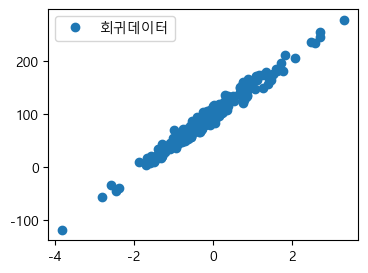

In [46]:
plt.figure(figsize=(4,3))
plt.plot(X0, y, 'o', label='회귀데이터')
plt.legend()
plt.show()

In [47]:
X0.shape, y.shape

((200, 1), (200,))

In [48]:
X0[:5], y[:5]

(array([[-0.13664932],
        [-0.14976664],
        [ 0.00159174],
        [-0.07679857],
        [-0.8897683 ]]),
 array([ 91.93982496, 104.5737146 , 115.90171564,  84.84487454,
         44.88407315]))

In [50]:
from sklearn.linear_model import LinearRegression
classifier = LinearRegression()
model = classifier.fit(X0,y)

In [51]:
type(classifier),type(model)

(sklearn.linear_model._base.LinearRegression,
 sklearn.linear_model._base.LinearRegression)

In [ ]:
y_new = model.predcit(x_new)

In [53]:
model.coef_ # 기울기, 가중치

array([54.48664769])

In [55]:
model.intercept_ # 상수항, 절편, 편향

np.float64(100.01474440528112)

- 기울기 (가중치)
- 상수항 (절편, 편향)

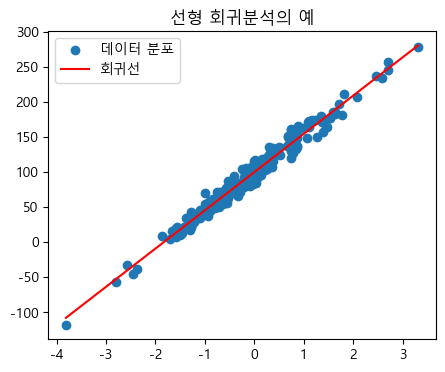

In [66]:
plt.figure(figsize=(5,4))

# 회귀분석 결과를 시각화 한다.
pred_space = np.linspace(X0.min(), X0.max()).reshape(-1,1)
pred_y = model.predict(pred_space)

# 산점도를 그려 봅니다.
# plt.plot(X0, y, 'o', label='데이터 분포')
plt.scatter(X0, y, label='데이터 분포')

# 회귀선 
plt.plot(pred_space,pred_y, 'r-', label='회귀선')
plt.title('선형 회귀분석의 예')
plt.legend()
plt.show()

In [71]:
# X0의 min, max
X0.min(), X0.max()

(np.float64(-3.809890377851563), np.float64(3.3140753455120797))

In [72]:
# 새 데이터 [3.0] 의 예측
pred_new = model.predict([[3.0]])
pred_new

array([263.47468746])

In [73]:
plt.figure(figsize=(5,4))

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

In [80]:
new_x = [[3.9]]
pred_new2 = model.predict(new_x)
pred_new2

array([312.51267038])

<Figure size 500x400 with 0 Axes>

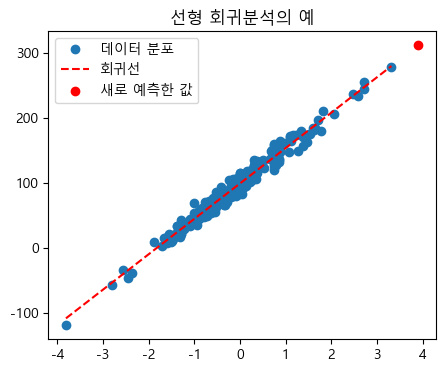

In [81]:
plt.figure(figsize=(5,4))
# 새로 예측한 결과를 시각화 한다.
plt.figure(figsize=(5,4))

# 회귀분석 결과를 시각화 한다.
pred_space = np.linspace(X0.min(), X0.max()).reshape(-1,1)
pred_y = model.predict(pred_space)

# 산점도를 그려 봅니다.
plt.plot(X0, y, 'o', label='데이터 분포')

# 회귀선 
plt.plot(pred_space , pred_y, 'r--', label='회귀선')

# 새로 예측한 결과
# plt.scatter([3.0], pred_new, c='red', label="새로 예측한 값")
plt.scatter([3.9], pred_new2, c='red', label="새로 예측한 값")

plt.title('선형 회귀분석의 예')
plt.legend()
plt.show()

# 다중 회귀 분석

In [85]:
df = pd.read_csv('d/Advertising.csv')
df.head()

,Unnamed: 0,FB,TV,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [88]:
# 입력 변수로 사용하지 않는 Unnamed: 0 변수 데이터를 삭제합니다.
df.drop('Unnamed: 0', axis=1, inplace=True)
df.head()

,FB,TV,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [94]:
# 1.피처 데이터를 선택
X = df.drop('Sales', axis=1).values
# 2. Sales 변수는 label 데이터 Y에 저장
y = df.Sales.values

In [95]:
X.shape, y.shape

((200, 3), (200,))

In [96]:
#2. 학습용 평가용 데이터로 분리합니다.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=50)

In [120]:
from sklearn.linear_model import LinearRegression

#1. 다중 선형 회귀 모델을 초기화하고 학습합니다
   # 모델 초기화
  # train data로 학습
lg_clf = LinearRegression()
lg_clf.fit(X_train, y_train)

#2. 학습된 결과:
   # y절편 (기본 판매량)
     # 1번째 변수에 대한 계수 (페이스북)
     # 2번째 변수에 대한 계수 (TV)
     # 3번째 변수에 대한 계수 (신문)

beta_0 = lg_clf.intercept_
beta_1 = lg_clf.coef_[0]
beta_2 = lg_clf.coef_[1]
beta_3 = lg_clf.coef_[2]

print("beta_0: %f" % beta_0)  # beta_0: 2.979067
print("beta_1: %f" % beta_1)  # beta_1: 0.044730
print("beta_2: %f" % beta_2)  # beta_2: 0.189195
print("beta_3: %f" % beta_3)  # beta_3: 0.002761


beta_0: 2.709490
beta_1: 0.047550
beta_2: 0.180880
beta_3: 0.006298


In [108]:
# test_X에 대해서 예측합니다.
pred_X = lg_clf.predict(X_test)
print('test_X에 대한 예측값 : \n{}\n'.format(pred_X))

test_X에 대한 예측값 : 
[13.86471261 15.0090562  10.60511722 10.09061905 10.2058302  18.44112845
 15.35623109  3.50456716 20.57163267 11.98288476 15.08601123 12.84835102
 21.13029782 14.37916353 15.96630443 16.97004665 10.28916068 16.78706185
  9.5680503  12.51794578 16.90028224 10.16656637  8.06620555 13.98212973
 21.32738303 14.23529429  7.20839801  7.55987252 15.4385442  13.60561012
 14.89945663 10.22068212 11.980595   16.40933006  6.58023303  9.63142726
 12.99984158 20.51038927  9.15336417 11.31226434  7.30108894 24.61494601
  9.80946097 18.27320104 16.57103149 12.0584219  12.43507395 16.11514576
  8.76566004  7.84595288 12.21810153 12.07628047 14.37606032 10.49776835
 17.58332133 16.68505237 16.43189148  3.56597841 23.2024176  13.2715782 ]



In [111]:
X_test[-1], y_test[-1] # 모델 예측값은  13.2715782 실제값은 12.5로 나옴

(array([ 67.8,  36.6, 114. ]), np.float64(12.5))

In [114]:
for c in df.columns:
    print(f'{c}: {df[c].min()}, {df[c].max()}')

FB: 0.7, 296.4
TV: 0.0, 49.6
Newspaper: 0.3, 114.0
Sales: 1.6, 27.0


In [119]:
# 새로운 데이터 df1을 정의합니다
# df1 = pd.DataFrame(np.array([[0.5, 30, 70], [50, 39, 60], [90, 70, 80], [70, 40, 2], [10, 10, 10]]),
#                     columns=['FB', 'TV', 'Newspaper'])
df1 = pd.DataFrame(np.array([[0.5, 30, 70], [50, 39, 60], [90, 70, 0], [70, 40, 0], [10, 10, 0]]),
                    columns=['FB', 'TV', 'Newspaper'])
print('df1 : ')
print(df1)


df1 : 
     FB    TV  Newspaper
0   0.5  30.0       70.0
1  50.0  39.0       60.0
2  90.0  70.0        0.0
3  70.0  40.0        0.0
4  10.0  10.0        0.0


In [118]:
#2. df1에 대해서 예측합니다.
pred_df1 = lg_clf.predict(df1.values)
print('df1에 대한 예측값 : \n{}'.format(pred_df1))

df1에 대한 예측값 : 
[ 8.60053306 12.519204   20.15445383 13.28579927  5.05677296]


In [ ]:
# 1. train_X 의 MSE, MAE 값을 계산합니다
MSE_train = mean_squared_error(y_train, pred_train)
MAE_train = mean_absolute_error(y_train, pred_train)

print('MSE_train : %f' % MSE_train)  # MSE_train : 2.705129
print('MAE_train : %f' % MAE_train)  # MAE_train : 1.198468

# test_X 의 예측값을 계산합니다
pred_test = lg_clf2.predict(X_test)

# 2. test_X 의 MSE, MAE 값을 계산합니다
MSE_test = mean_squared_error(y_test, pred_test)
MAE_test = mean_absolute_error(y_test, pred_test)

print('MSE_test : %f' % MSE_test)  # MSE_test : 3.174097
print('MAE_test : %f' % MAE_test)  # MAE_test : 1.460757

MSE_train : 2.963396
MAE_train : 1.301587
MSE_test : 2.170545
MAE_test : 1.134187


In [125]:
# RMSE rooted MSE
np.sqrt(MSE_train), np.sqrt(MSE_test)

(np.float64(1.7214518170826192), np.float64(1.4732770196181149))